In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt 

In [5]:
import seaborn as sns

In [6]:
df = pd.read_csv(r"C:\Users\SANCHIT\Downloads\Customer Segmentation.csv")

In [7]:
df.head()

,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount_USD,Location,Size,Color,Season,Review_Rating,Subscription_Status,Payment_Method,Shipping_Type,Discount_Applied,Promo_Code_Used,Previous_Purchases,Preferred_Payment_Method,Frequency_of_Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [8]:
df.shape

(3900, 19)

In [9]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category',
       'Purchase_Amount_USD', 'Location', 'Size', 'Color', 'Season',
       'Review_Rating', 'Subscription_Status', 'Payment_Method',
       'Shipping_Type', 'Discount_Applied', 'Promo_Code_Used',
       'Previous_Purchases', 'Preferred_Payment_Method',
       'Frequency_of_Purchases'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item_Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase_Amount_USD       3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review_Rating             3900 non-null   float64
 11  Subscription_Status       3900 non-null   object 
 12  Payment_Method            3900 non-null   object 
 13  Shipping_Type             3900 non-null   object 
 14  Discount

In [11]:
df.describe()

,Customer_ID,Age,Purchase_Amount_USD,Review_Rating,Previous_Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [12]:
df.select_dtypes(include='number')

,Customer_ID,Age,Purchase_Amount_USD,Review_Rating,Previous_Purchases
0,1,55,53,3.1,14
1,2,19,64,3.1,2
2,3,50,73,3.1,23
3,4,21,90,3.5,49
4,5,45,49,2.7,31
...,...,...,...,...,...
3895,3896,40,28,4.2,32
3896,3897,52,49,4.5,41
3897,3898,46,33,2.9,24
3898,3899,44,77,3.8,24


In [13]:
x = df[["Age","Purchase_Amount_USD","Previous_Purchases","Review_Rating"]]

In [14]:
x.head()

,Age,Purchase_Amount_USD,Previous_Purchases,Review_Rating
0,55,53,14,3.1
1,19,64,2,3.1
2,50,73,23,3.1
3,21,90,49,3.5
4,45,49,31,2.7


In [15]:
from sklearn.preprocessing import StandardScaler


In [16]:
X = df[['Age', 'Purchase_Amount_USD', 'Review_Rating', 'Previous_Purchases']]

In [17]:
X.head()

,Age,Purchase_Amount_USD,Review_Rating,Previous_Purchases
0,55,53,3.1,14
1,19,64,3.1,2
2,50,73,3.1,23
3,21,90,3.5,49
4,45,49,2.7,31


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [19]:
X_scaled

array([[ 0.71891344, -0.28562864, -0.90758357, -0.78583067],
       [-1.64862924,  0.17885219, -0.90758357, -1.61655226],
       [ 0.39008807,  0.55888195, -0.90758357, -0.16278948],
       ...,
       [ 0.12702777, -1.13013923, -1.18686209, -0.09356268],
       [-0.00450238,  0.72778407,  0.06989124, -0.09356268],
       [ 0.52161822,  0.89668619, -0.90758357,  0.52947851]])

In [20]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.head()

,Age,Purchase_Amount_USD,Review_Rating,Previous_Purchases
0,0.718913,-0.285629,-0.907584,-0.785831
1,-1.648629,0.178852,-0.907584,-1.616552
2,0.390088,0.558882,-0.907584,-0.162789
3,-1.517099,1.276716,-0.349027,1.637107
4,0.061263,-0.454531,-1.466141,0.391025


In [21]:
from sklearn.cluster import KMeans 

In [22]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

In [23]:
wcss

[15599.999999999995,
 12630.104664458673,
 10840.216258591412,
 9408.412170781015,
 8335.187966531716,
 7523.349481829789,
 6781.631912811074,
 6000.597866765208,
 5626.398180924605,
 5284.619067293504]

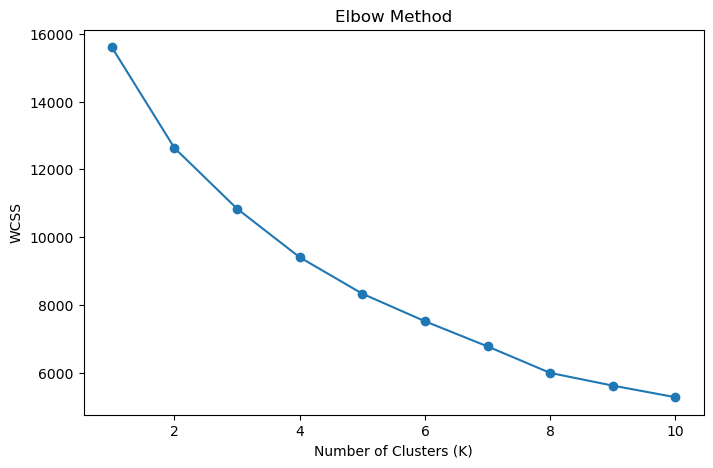

In [24]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

In [25]:
kmeans = KMeans(n_clusters=5, random_state=42)

In [26]:
clusters = kmeans.fit_predict(X_scaled)

In [27]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

In [28]:
clusters

array([4, 2, 4, ..., 3, 0, 3], dtype=int32)

In [29]:
df['Cluster'] = clusters

In [30]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

df.head()

,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount_USD,Location,Size,Color,Season,Review_Rating,Subscription_Status,Payment_Method,Shipping_Type,Discount_Applied,Promo_Code_Used,Previous_Purchases,Preferred_Payment_Method,Frequency_of_Purchases,Cluster
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly,4
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly,2
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly,4
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly,2
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually,3


In [31]:
df.head()

,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount_USD,Location,Size,Color,Season,Review_Rating,Subscription_Status,Payment_Method,Shipping_Type,Discount_Applied,Promo_Code_Used,Previous_Purchases,Preferred_Payment_Method,Frequency_of_Purchases,Cluster
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly,4
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly,2
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly,4
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly,2
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually,3


In [32]:
df.groupby('Cluster').mean(numeric_only=True)

,Customer_ID,Age,Purchase_Amount_USD,Review_Rating,Previous_Purchases
Cluster,,,,,
0,1960.017964,50.579641,77.838323,4.387904,33.126946
1,1939.788030,35.102244,39.102244,4.286160,19.145885
2,1968.471409,28.690377,78.673640,3.420084,21.281729
3,1907.810644,48.045792,44.753713,3.249629,38.641089
4,1980.650407,57.031165,59.831978,3.313686,12.701897


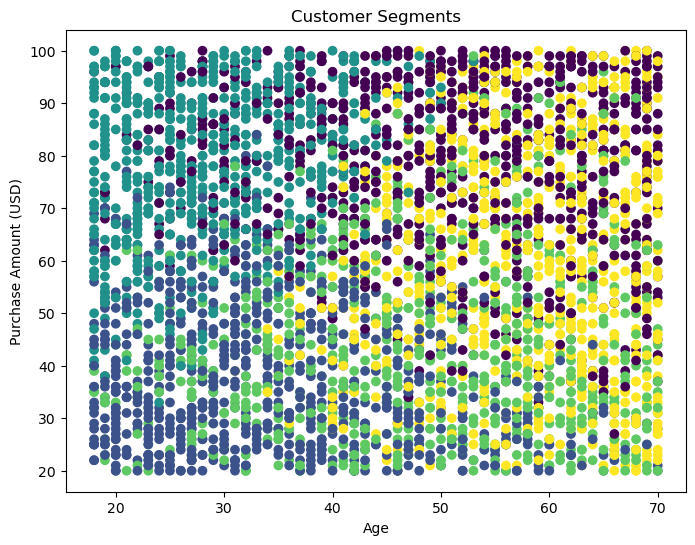

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['Age'], df['Purchase_Amount_USD'], c=df['Cluster'])
plt.xlabel('Age')
plt.ylabel('Purchase Amount (USD)')
plt.title('Customer Segments')
plt.show()

In [34]:
df['Cluster'].value_counts()

Cluster
0    835
3    808
1    802
4    738
2    717
Name: count, dtype: int64

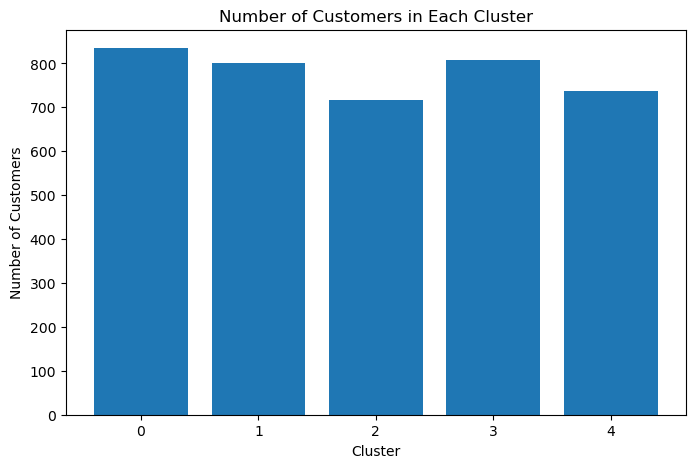

In [35]:
import matplotlib.pyplot as plt

cluster_counts = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(cluster_counts.index, cluster_counts.values)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [36]:
avg_purchase = df.groupby('Cluster')['Purchase_Amount_USD'].mean()

avg_purchase

Cluster
0    77.838323
1    39.102244
2    78.673640
3    44.753713
4    59.831978
Name: Purchase_Amount_USD, dtype: float64

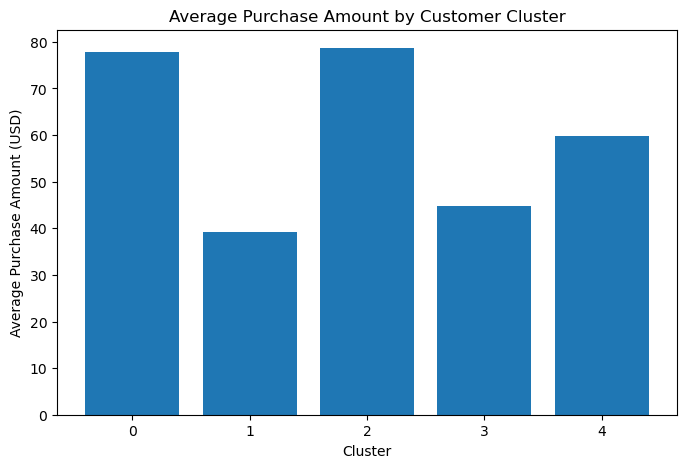

In [37]:
plt.figure(figsize=(8,5))

plt.bar(avg_purchase.index, avg_purchase.values)

plt.title("Average Purchase Amount by Customer Cluster")

plt.xlabel("Cluster")

plt.ylabel("Average Purchase Amount (USD)")

plt.show()

In [38]:
avg_review = df.groupby('Cluster')['Review_Rating'].mean()

avg_review

Cluster
0    4.387904
1    4.286160
2    3.420084
3    3.249629
4    3.313686
Name: Review_Rating, dtype: float64

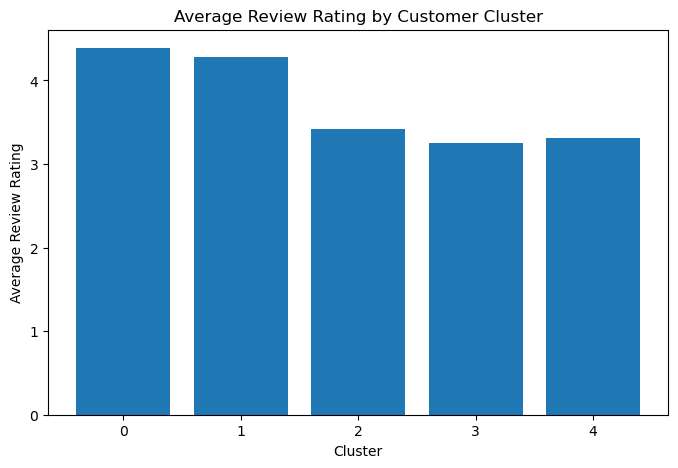

In [39]:
plt.figure(figsize=(8,5))

plt.bar(avg_review.index, avg_review.values)

plt.title("Average Review Rating by Customer Cluster")

plt.xlabel("Cluster")

plt.ylabel("Average Review Rating")

plt.show()

In [40]:
avg_age = df.groupby('Cluster')['Age'].mean()

avg_age

Cluster
0    50.579641
1    35.102244
2    28.690377
3    48.045792
4    57.031165
Name: Age, dtype: float64

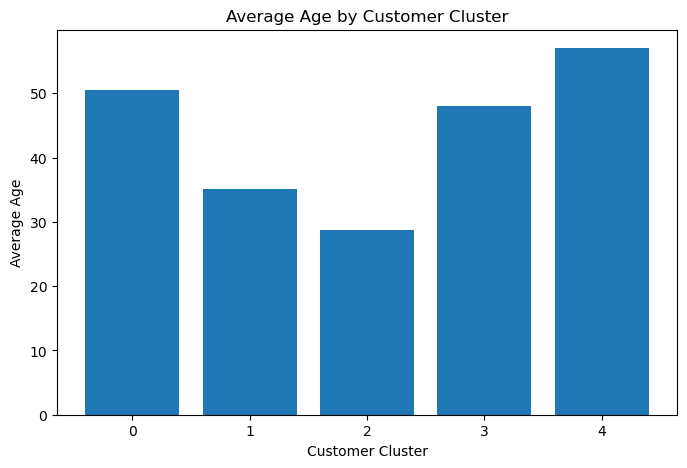

In [41]:
plt.figure(figsize=(8,5))

plt.bar(avg_age.index, avg_age.values)

plt.title("Average Age by Customer Cluster")

plt.xlabel("Customer Cluster")

plt.ylabel("Average Age")

plt.show()

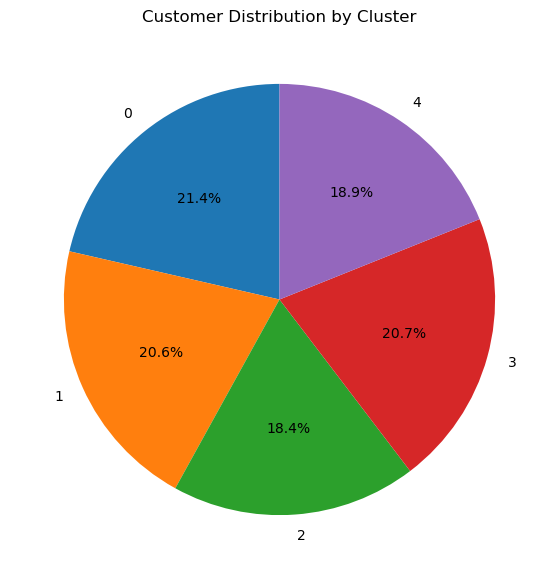

In [42]:
cluster_counts = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(7,7))

plt.pie(cluster_counts.values,
        labels=cluster_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Customer Distribution by Cluster")

plt.show()